In [12]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Optional, Sequence, Literal
import numpy as np
from numpy.typing import NDArray

Array = NDArray[np.complex128]


@dataclass
class UQNGilbertResult:
    distance: float
    squared_distance: float
    sigma: Array
    iterations: int
    converged: bool
    history: list[float]
    last_oracle_info: dict


def ketbra(psi: Array) -> Array:
    psi = np.asarray(psi, dtype=np.complex128).reshape(-1)
    nrm = np.linalg.norm(psi)

    if nrm <= 1e-15:
        raise ValueError("Cannot form ketbra from a zero vector.")

    psi = psi / nrm
    return np.outer(psi, psi.conj()).astype(np.complex128)


def hs_inner(a: Array, b: Array) -> float:
    return float(np.real(np.trace(a.conj().T @ b)))


def hs_norm(a: Array) -> float:
    return float(np.sqrt(max(hs_inner(a, a), 0.0)))


def hs_distance(a: Array, b: Array) -> float:
    return hs_norm(a - b)


def random_unit_vector(dim: int, rng: np.random.Generator) -> Array:
    z = rng.normal(size=dim) + 1j * rng.normal(size=dim)
    return (z / np.linalg.norm(z)).astype(np.complex128)


def haar_random_unitary(dim: int, rng: np.random.Generator) -> Array:
    z = rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))
    q, r = np.linalg.qr(z)

    diag = np.diag(r)
    phase = diag / np.where(np.abs(diag) > 0.0, np.abs(diag), 1.0)

    q = q * phase.conj()
    return q.astype(np.complex128)


def qiskit_3q_to_internal_abc_order(
    rho_qiskit: Array,
    qubit_order: Sequence[int] = (0, 1, 2),
) -> Array:
    """
    Convert a Qiskit little-endian 3-qubit density matrix to internal ABC order.

    Internal basis:
        |ABC> with A as the most significant bit.

    Qiskit basis:
        index = bit(q0)*2^0 + bit(q1)*2^1 + bit(q2)*2^2

    qubit_order:
        Which Qiskit qubits correspond to internal A, B, C.

    Example:
        qubit_order=(0,1,2) means:
            A = Qiskit qubit 0
            B = Qiskit qubit 1
            C = Qiskit qubit 2
    """
    rho_qiskit = np.asarray(rho_qiskit, dtype=np.complex128)

    if rho_qiskit.shape != (8, 8):
        raise ValueError(f"Expected 8x8 matrix, got {rho_qiskit.shape}")

    qubit_order = tuple(int(q) for q in qubit_order)

    if sorted(qubit_order) != [0, 1, 2]:
        raise ValueError("qubit_order must be a permutation of (0, 1, 2).")

    p = []

    for internal_index in range(8):
        # Internal bits are A,B,C from MSB to LSB.
        bits_abc = [
            (internal_index >> 2) & 1,
            (internal_index >> 1) & 1,
            internal_index & 1,
        ]

        bits_by_qiskit_qubit = {
            qubit_order[pos]: bits_abc[pos]
            for pos in range(3)
        }

        qiskit_index = sum(
            bits_by_qiskit_qubit[q] << q
            for q in range(3)
        )

        p.append(qiskit_index)

    p = np.asarray(p, dtype=int)

    return rho_qiskit[np.ix_(p, p)].astype(np.complex128)


def internal_abc_to_qiskit_3q_order(
    rho_internal: Array,
    qubit_order: Sequence[int] = (0, 1, 2),
) -> Array:
    """
    Inverse of qiskit_3q_to_internal_abc_order.
    """
    rho_internal = np.asarray(rho_internal, dtype=np.complex128)

    if rho_internal.shape != (8, 8):
        raise ValueError(f"Expected 8x8 matrix, got {rho_internal.shape}")

    qubit_order = tuple(int(q) for q in qubit_order)

    if sorted(qubit_order) != [0, 1, 2]:
        raise ValueError("qubit_order must be a permutation of (0, 1, 2).")

    p = []

    for internal_index in range(8):
        bits_abc = [
            (internal_index >> 2) & 1,
            (internal_index >> 1) & 1,
            internal_index & 1,
        ]

        bits_by_qiskit_qubit = {
            qubit_order[pos]: bits_abc[pos]
            for pos in range(3)
        }

        qiskit_index = sum(
            bits_by_qiskit_qubit[q] << q
            for q in range(3)
        )

        p.append(qiskit_index)

    p = np.asarray(p, dtype=int)

    rho_qiskit = np.empty_like(rho_internal)
    rho_qiskit[np.ix_(p, p)] = rho_internal

    return rho_qiskit.astype(np.complex128)


def as_3q_density_matrix(
    rho_like: Any,
    input_order: Literal["qiskit", "internal"] = "qiskit",
    qiskit_qubit_order: Sequence[int] = (0, 1, 2),
    psd_tol: float = 1e-8,
) -> Array:
    """
    Convert input to a normalized internal-order 3-qubit 8x8 density matrix.

    Accepted:
        numpy.ndarray, shape (8,8)
        numpy.ndarray statevector, shape (8,)
        qiskit.quantum_info.DensityMatrix
        qiskit.quantum_info.Statevector

    Rejected:
        QuantumCircuit objects.
    """
    class_name = rho_like.__class__.__name__

    if class_name == "QuantumCircuit":
        raise TypeError(
            "This version accepts only precomputed 3-qubit states. "
            "Simulate externally and pass the resulting 8x8 DensityMatrix."
        )

    source_is_qiskit_object = class_name in {"DensityMatrix", "Statevector"}

    if hasattr(rho_like, "data"):
        rho_like = rho_like.data

    arr = np.asarray(rho_like, dtype=np.complex128)

    if arr.shape == (8,):
        psi = arr / np.linalg.norm(arr)

        if input_order == "qiskit" or source_is_qiskit_object:
            rho = ketbra(psi)
            rho = qiskit_3q_to_internal_abc_order(rho, qiskit_qubit_order)
        elif input_order == "internal":
            rho = ketbra(psi)
        else:
            raise ValueError("input_order must be 'qiskit' or 'internal'.")

    elif arr.shape == (8, 8):
        rho = arr

        if input_order == "qiskit" or source_is_qiskit_object:
            rho = qiskit_3q_to_internal_abc_order(rho, qiskit_qubit_order)
        elif input_order == "internal":
            pass
        else:
            raise ValueError("input_order must be 'qiskit' or 'internal'.")

    else:
        raise ValueError(
            f"Expected a 3-qubit statevector shape (8,) or density matrix "
            f"shape (8,8). Got {arr.shape}."
        )

    rho = (rho + rho.conj().T) / 2

    tr = np.trace(rho)

    if abs(tr) <= 1e-14:
        raise ValueError("Density matrix has zero trace.")

    rho = rho / tr

    eig_min = float(np.min(np.linalg.eigvalsh(rho)))

    if eig_min < -psd_tol:
        raise ValueError(f"Input is not positive semidefinite. min eigenvalue = {eig_min:g}")

    return rho.astype(np.complex128)


def partial_trace_one_ancilla_per_party_from_6q_pure(psi6: Array) -> Array:
    """
    Trace out one ancilla qubit per party from a six-qubit pure state.

    Axis convention for psi6:
        [A_visible, A_ancilla, B_visible, B_ancilla, C_visible, C_ancilla]

    Returned density matrix is 8x8 on:
        [A_visible, B_visible, C_visible]
    """
    psi6 = np.asarray(psi6, dtype=np.complex128).reshape(2, 2, 2, 2, 2, 2)

    # Keep axes A_visible, B_visible, C_visible = 0,2,4.
    # Trace axes A_ancilla, B_ancilla, C_ancilla = 1,3,5.
    psi_perm = np.transpose(psi6, (0, 2, 4, 1, 3, 5)).reshape(8, 8)

    rho3 = psi_perm @ psi_perm.conj().T
    rho3 = (rho3 + rho3.conj().T) / 2
    rho3 = rho3 / np.trace(rho3)

    return rho3.astype(np.complex128)


def random_triangle_uqn_reduced_atom_3q(rng: np.random.Generator) -> Array:
    """
    Sample one reduced 3-qubit atom from the tripartite triangle UQN construction.

    Six-qubit pure network construction:

        |s_AB>_{A0 B0} ⊗ |s_BC>_{B1 C0} ⊗ |s_CA>_{C1 A1}

    followed by local 4x4 unitaries:

        U_A on A0A1
        U_B on B0B1
        U_C on C0C1

    Then trace out one local ancilla qubit per party, giving an 8x8
    three-qubit network-state RDM.

    This implements the paper's 3-qubit strategy in reduced 8x8 form.
    """
    s_ab = random_unit_vector(4, rng).reshape(2, 2)  # A0, B0
    s_bc = random_unit_vector(4, rng).reshape(2, 2)  # B1, C0
    s_ca = random_unit_vector(4, rng).reshape(2, 2)  # C1, A1

    # raw axes:
    #   s_ab[a0,b0], s_bc[b1,c0], s_ca[c1,a1]
    #
    # desired party-grouped six-qubit axes:
    #   A0,A1,B0,B1,C0,C1
    raw = np.einsum("ab,cd,ef->afbcde", s_ab, s_bc, s_ca)
    raw = raw.reshape(4, 4, 4)  # A=(A0A1), B=(B0B1), C=(C0C1)

    U_A = haar_random_unitary(4, rng)
    U_B = haar_random_unitary(4, rng)
    U_C = haar_random_unitary(4, rng)

    psi_abc4 = np.einsum("ia,jb,kc,abc->ijk", U_A, U_B, U_C, raw)
    psi6 = psi_abc4.reshape(2, 2, 2, 2, 2, 2).reshape(64)

    return partial_trace_one_ancilla_per_party_from_6q_pure(psi6)


def random_product_atom_3q(rng: np.random.Generator) -> Array:
    a = random_unit_vector(2, rng)
    b = random_unit_vector(2, rng)
    c = random_unit_vector(2, rng)

    psi = np.einsum("a,b,c->abc", a, b, c).reshape(8)
    return ketbra(psi)


def random_biseparable_atom_3q(rng: np.random.Generator) -> Array:
    """
    Sample a pure biseparable 3-qubit atom.

    These are included because biseparable states are UQN/network states,
    and including them makes the oracle less fragile.
    """
    cut = int(rng.integers(0, 3))

    if cut == 0:
        # A | BC
        a = random_unit_vector(2, rng)
        bc = random_unit_vector(4, rng).reshape(2, 2)
        psi = np.einsum("a,bc->abc", a, bc).reshape(8)

    elif cut == 1:
        # B | AC
        b = random_unit_vector(2, rng)
        ac = random_unit_vector(4, rng).reshape(2, 2)
        psi = np.einsum("b,ac->abc", b, ac).reshape(2, 2, 2)
        psi = np.transpose(psi, (1, 0, 2)).reshape(8)

    else:
        # C | AB
        c = random_unit_vector(2, rng)
        ab = random_unit_vector(4, rng).reshape(2, 2)
        psi = np.einsum("c,ab->abc", c, ab).reshape(2, 2, 2)
        psi = np.transpose(psi, (1, 2, 0)).reshape(8)

    return ketbra(psi)


def computational_basis_atoms_3q() -> list[Array]:
    atoms = []

    for k in range(8):
        v = np.zeros(8, dtype=np.complex128)
        v[k] = 1.0
        atoms.append(ketbra(v))

    return atoms


def ghz3_density() -> Array:
    psi = np.zeros(8, dtype=np.complex128)
    psi[0] = 1.0 / np.sqrt(2)
    psi[7] = 1.0 / np.sqrt(2)
    return ketbra(psi)


def w3_density() -> Array:
    psi = np.zeros(8, dtype=np.complex128)
    # Internal |ABC> order: |001>, |010>, |100>.
    psi[1] = 1.0 / np.sqrt(3)
    psi[2] = 1.0 / np.sqrt(3)
    psi[4] = 1.0 / np.sqrt(3)
    return ketbra(psi)


def white_noise_mixture_3q(rho: Array, p: float) -> Array:
    rho = np.asarray(rho, dtype=np.complex128)

    if rho.shape != (8, 8):
        raise ValueError("rho must be 8x8.")

    return (1.0 - p) * rho + p * np.eye(8, dtype=np.complex128) / 8


class ReducedTriangleUQNOracle3Q:
    """
    Linear oracle over reduced tripartite UQN atoms.

    Given G = rho - sigma on the 3-qubit system, this approximately solves:

        max_{tau in reduced-UQN-atoms} Tr(G tau)

    where tau is the 8x8 RDM obtained by:
        six-qubit triangle UQN pure state -> trace one ancilla per party.

    The global optimization is nonconvex, so this is a stochastic oracle.
    Increase triangle_samples for better accuracy.
    """

    def __init__(
        self,
        triangle_samples: int = 400,
        biseparable_samples: int = 80,
        product_samples: int = 40,
        seed: Optional[int] = None,
    ) -> None:
        self.triangle_samples = int(triangle_samples)
        self.biseparable_samples = int(biseparable_samples)
        self.product_samples = int(product_samples)
        self.rng = np.random.default_rng(seed)

    def sample_atom(self, kind: Literal["triangle", "biseparable", "product"] = "triangle") -> Array:
        if kind == "triangle":
            return random_triangle_uqn_reduced_atom_3q(self.rng)

        if kind == "biseparable":
            return random_biseparable_atom_3q(self.rng)

        if kind == "product":
            return random_product_atom_3q(self.rng)

        raise ValueError("kind must be 'triangle', 'biseparable', or 'product'.")

    def __call__(self, G: Array) -> tuple[Array, dict]:
        G = (G + G.conj().T) / 2

        best_val = -np.inf
        best_tau: Optional[Array] = None
        best_kind = ""

        for _ in range(self.triangle_samples):
            tau = random_triangle_uqn_reduced_atom_3q(self.rng)
            val = hs_inner(G, tau)

            if val > best_val:
                best_val = val
                best_tau = tau
                best_kind = "triangle"

        for _ in range(self.biseparable_samples):
            tau = random_biseparable_atom_3q(self.rng)
            val = hs_inner(G, tau)

            if val > best_val:
                best_val = val
                best_tau = tau
                best_kind = "biseparable"

        for _ in range(self.product_samples):
            tau = random_product_atom_3q(self.rng)
            val = hs_inner(G, tau)

            if val > best_val:
                best_val = val
                best_tau = tau
                best_kind = "product"

        if best_tau is None:
            raise RuntimeError("UQN oracle failed to sample any candidate atom.")

        return best_tau, {
            "oracle": "ReducedTriangleUQNOracle3Q",
            "expectation": float(best_val),
            "best_kind": best_kind,
            "triangle_samples": self.triangle_samples,
            "biseparable_samples": self.biseparable_samples,
            "product_samples": self.product_samples,
        }


def project_to_simplex(v: NDArray[np.float64]) -> NDArray[np.float64]:
    """
    Euclidean projection onto:
        {x_i >= 0, sum_i x_i = 1}
    """
    v = np.asarray(v, dtype=float)

    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - 1.0
    ind = np.arange(1, len(v) + 1)

    cond = u - cssv / ind > 0

    if not np.any(cond):
        return np.ones_like(v) / len(v)

    rho = ind[cond][-1]
    theta = cssv[cond][-1] / rho

    return np.maximum(v - theta, 0.0)


def simplex_project_fista(
    rho: Array,
    states: Sequence[Array],
    max_steps: int = 1500,
    tol: float = 1e-12,
) -> Array:
    """
    Gilbert-with-memory simplex/QP step.

    Solves:

        min_x ||A x - vec(rho)||_2^2
        s.t. x_i >= 0, sum_i x_i = 1

    where columns of A are vectorized RDM atoms.

    This is the page-9 improvement replacing ordinary line search.
    """
    if len(states) == 0:
        raise ValueError("states must contain at least one density matrix.")

    A = np.stack([s.reshape(-1) for s in states], axis=1)
    b = rho.reshape(-1)

    Q = np.real(A.conj().T @ A)
    c = np.real(A.conj().T @ b)

    m = len(states)
    x = np.ones(m, dtype=float) / m
    y = x.copy()
    t = 1.0

    Qsym = (Q + Q.T) / 2
    eig_max = max(float(np.linalg.eigvalsh(Qsym)[-1]), 1e-15)

    # Objective is ||Ax-b||^2 = x^T Q x - 2 c^T x + const.
    # Gradient Lipschitz constant is 2*lambda_max(Q).
    L = 2.0 * eig_max

    for _ in range(max_steps):
        grad = 2.0 * (Q @ y - c)
        x_new = project_to_simplex(y - grad / L)

        if np.linalg.norm(x_new - x, ord=1) < tol:
            x = x_new
            break

        t_new = (1.0 + np.sqrt(1.0 + 4.0 * t * t)) / 2.0
        y = x_new + ((t - 1.0) / t_new) * (x_new - x)

        x = x_new
        t = t_new

    sigma = sum(float(w) * s for w, s in zip(x, states))
    sigma = (sigma + sigma.conj().T) / 2
    sigma = sigma / np.trace(sigma)

    return sigma.astype(np.complex128)


def simplex_project_cvxpy_mosek(rho: Array, states: Sequence[Array]) -> Array:
    """
    Optional CVXPY + MOSEK version of the Gilbert-with-memory QP.

    This is a convex quadratic program, not an SDP.
    """
    import cvxpy as cp

    if len(states) == 0:
        raise ValueError("states must contain at least one density matrix.")

    A = np.stack([s.reshape(-1) for s in states], axis=1)
    b = rho.reshape(-1)

    m = len(states)
    x = cp.Variable(m)

    residual = A @ x - b

    problem = cp.Problem(
        cp.Minimize(
            cp.sum_squares(cp.real(residual))
            + cp.sum_squares(cp.imag(residual))
        ),
        [
            x >= 0,
            cp.sum(x) == 1,
        ],
    )

    problem.solve(solver=cp.MOSEK, verbose=False)

    if x.value is None:
        raise RuntimeError("CVXPY/MOSEK failed to solve the memory QP.")

    weights = np.asarray(x.value, dtype=float)
    weights = np.maximum(weights, 0.0)
    weights = weights / np.sum(weights)

    sigma = sum(float(w) * s for w, s in zip(weights, states))
    sigma = (sigma + sigma.conj().T) / 2
    sigma = sigma / np.trace(sigma)

    return sigma.astype(np.complex128)


def line_search_update(rho: Array, sigma: Array, tau: Array) -> Array:
    """
    Ordinary Gilbert line search.

    This is retained as a fallback, but the default uses the page-9
    Gilbert-with-memory simplex step instead.
    """
    delta = sigma - tau
    denom = hs_inner(delta, delta)

    if denom <= 1e-15:
        return sigma

    p_star = hs_inner(rho - tau, delta) / denom
    p_star = float(np.clip(p_star, 0.0, 1.0))

    out = p_star * sigma + (1.0 - p_star) * tau
    out = (out + out.conj().T) / 2
    out = out / np.trace(out)

    return out.astype(np.complex128)


def gilbert_uqn_distance_3q(
    rho_like: Any,
    input_order: Literal["qiskit", "internal"] = "qiskit",
    qiskit_qubit_order: Sequence[int] = (0, 1, 2),
    max_iter: int = 120,
    memory: int = 50,
    gap_tol: float = 1e-9,
    distance_tol: float = 1e-10,
    triangle_samples: int = 400,
    biseparable_samples: int = 80,
    product_samples: int = 40,
    initial_triangle_atoms: int = 30,
    initial_biseparable_atoms: int = 20,
    keep_computational_basis_atoms: bool = True,
    use_mosek_for_memory_qp: bool = False,
    qp_steps: int = 1500,
    qp_tol: float = 1e-12,
    seed: Optional[int] = None,
) -> UQNGilbertResult:
    """
    Estimate the Hilbert-Schmidt distance from a 3-qubit state to the
    reduced tripartite UQN/network set.

    Input:
        8x8 density matrix, Qiskit DensityMatrix, or 8-vector statevector.

    Construction:
        1. Accept rho as an 8x8 3-qubit state.
        2. Sample six-qubit triangle-UQN pure states.
        3. Trace one ancilla qubit per party, giving 8x8 network-state RDM atoms.
        4. Run Gilbert's algorithm on the convex hull of these 8x8 RDM atoms.
        5. Replace ordinary line search with the page-9 Gilbert-with-memory
           simplex/QP update.

    Important:
        This is still a stochastic upper-bound estimator because the UQN
        boundary oracle is nonconvex and sampled.
    """
    rho = as_3q_density_matrix(
        rho_like,
        input_order=input_order,
        qiskit_qubit_order=qiskit_qubit_order,
    )

    dim = 8
    rng = np.random.default_rng(seed)

    oracle = ReducedTriangleUQNOracle3Q(
        triangle_samples=triangle_samples,
        biseparable_samples=biseparable_samples,
        product_samples=product_samples,
        seed=seed,
    )

    sigma = np.eye(dim, dtype=np.complex128) / dim

    fixed_atoms: list[Array] = []
    dynamic_atoms: list[Array] = []

    if keep_computational_basis_atoms:
        fixed_atoms.extend(computational_basis_atoms_3q())

    for _ in range(initial_triangle_atoms):
        dynamic_atoms.append(random_triangle_uqn_reduced_atom_3q(rng))

    for _ in range(initial_biseparable_atoms):
        dynamic_atoms.append(random_biseparable_atom_3q(rng))

    initial_states = [sigma] + fixed_atoms + dynamic_atoms

    sigma = (
        simplex_project_cvxpy_mosek(rho, initial_states)
        if use_mosek_for_memory_qp
        else simplex_project_fista(
            rho,
            initial_states,
            max_steps=qp_steps,
            tol=qp_tol,
        )
    )

    history = [hs_distance(rho, sigma)]

    if history[-1] <= distance_tol:
        return UQNGilbertResult(
            distance=0.0,
            squared_distance=0.0,
            sigma=sigma,
            iterations=0,
            converged=True,
            history=[float(history[-1])],
            last_oracle_info={
                "status": "initial UQN convex projection reached distance_tol",
                "initial_distance": float(history[-1]),
            },
        )

    last_info: dict = {}
    converged = False

    for it in range(1, max_iter + 1):
        # Gilbert descent direction.
        # We seek a network atom tau maximizing Tr[(rho - sigma) tau].
        G = rho - sigma

        tau, info = oracle(G)
        tau = (tau + tau.conj().T) / 2
        tau = tau / np.trace(tau)

        gap = hs_inner(G, tau - sigma)

        last_info = dict(info)
        last_info["gilbert_gap"] = float(gap)
        last_info["distance_before"] = float(history[-1])
        last_info["iteration"] = it

        if gap <= gap_tol:
            converged = True
            break

        dynamic_atoms.append(tau)

        if memory and memory > 1:
            # Page-9 Gilbert-with-memory update:
            # A = [vec(current sigma), vec(last M atoms)].
            memory_atoms = dynamic_atoms[-int(memory):]
            memory_states = [sigma] + memory_atoms

            sigma_new = (
                simplex_project_cvxpy_mosek(rho, memory_states)
                if use_mosek_for_memory_qp
                else simplex_project_fista(
                    rho,
                    memory_states,
                    max_steps=qp_steps,
                    tol=qp_tol,
                )
            )
        else:
            sigma_new = line_search_update(rho, sigma, tau)

        new_distance = hs_distance(rho, sigma_new)

        history.append(float(new_distance))

        last_info["distance_after"] = float(new_distance)
        last_info["distance_improvement"] = float(history[-2] - history[-1])

        sigma = sigma_new

        if new_distance <= distance_tol:
            converged = True
            break

    squared = hs_inner(rho - sigma, rho - sigma)

    return UQNGilbertResult(
        distance=float(np.sqrt(max(squared, 0.0))),
        squared_distance=float(max(squared, 0.0)),
        sigma=sigma,
        iterations=len(history) - 1,
        converged=converged,
        history=[float(x) for x in history],
        last_oracle_info=last_info,
    )


def run_dm_scan_3q(
    density_matrices_by_p: dict[float, Sequence[Any]],
    input_order: Literal["qiskit", "internal"] = "qiskit",
    qiskit_qubit_order: Sequence[int] = (0, 1, 2),
    base_seed: int = 1234,
    **distance_kwargs,
) -> dict:
    """
    Convenience function for precomputed 8x8 density matrices.

    density_matrices_by_p:
        {
            0.0: [dm0, dm1, ...],
            0.1: [dm0, dm1, ...],
            ...
        }
    """
    out = {
        "p_values": [],
        "means": [],
        "stderrs": [],
        "raw_distances": {},
        "results": {},
    }

    for p_index, p in enumerate(sorted(density_matrices_by_p.keys())):
        dms = density_matrices_by_p[p]

        Ds = []
        results = []

        print(f"Calculating p = {p}...")

        for k, dm in enumerate(dms):
            seed = base_seed + 100_000 * p_index + k

            res = gilbert_uqn_distance_3q(
                dm,
                input_order=input_order,
                qiskit_qubit_order=qiskit_qubit_order,
                seed=seed,
                **distance_kwargs,
            )

            Ds.append(res.distance)
            results.append(res)

            print(
                f"  sample {k}: "
                f"D={res.distance:.10g}, "
                f"iters={res.iterations}, "
                f"converged={res.converged}, "
                f"last={res.last_oracle_info}"
            )

        Ds_np = np.asarray(Ds, dtype=float)

        mean = float(np.mean(Ds_np))

        if len(Ds_np) > 1:
            stderr = float(np.std(Ds_np, ddof=1) / np.sqrt(len(Ds_np)))
        else:
            stderr = 0.0

        out["p_values"].append(float(p))
        out["means"].append(mean)
        out["stderrs"].append(stderr)
        out["raw_distances"][float(p)] = Ds
        out["results"][float(p)] = results

        print(f"p={p:.4g}, D={mean:.10g} ± {stderr:.3g}")

    return out


def purity_3q(rho_like: Any, input_order: Literal["qiskit", "internal"] = "qiskit") -> float:
    rho = as_3q_density_matrix(rho_like, input_order=input_order)
    return float(np.real(np.trace(rho @ rho)))


rho_mixed = np.eye(8, dtype=np.complex128) / 8

res_mixed = gilbert_uqn_distance_3q(
    rho_mixed,
    input_order="internal",
    max_iter=80,
    seed=1,
)

print("Maximally mixed")
print("D =", res_mixed.distance)
print("info =", res_mixed.last_oracle_info)
print()

rho_ghz = ghz3_density()

res_ghz = gilbert_uqn_distance_3q(
    rho_ghz,
    input_order="internal",
    max_iter=160,
    memory=70,
    triangle_samples=700,
    biseparable_samples=120,
    product_samples=40,
    initial_triangle_atoms=60,
    initial_biseparable_atoms=30,
    seed=2,
)

print("GHZ3")
print("D =", res_ghz.distance)
print("iters =", res_ghz.iterations)
print("info =", res_ghz.last_oracle_info)
print()

for p in [0.0, 0.3, 0.5, 0.57, 0.6, 0.72, 1.0]:
    rho_p = white_noise_mixture_3q(rho_ghz, p)

    res_p = gilbert_uqn_distance_3q(
        rho_p,
        input_order="internal",
        max_iter=140,
        memory=60,
        triangle_samples=500,
        biseparable_samples=100,
        product_samples=30,
        initial_triangle_atoms=40,
        initial_biseparable_atoms=20,
        seed=1000 + int(1000 * p),
    )

    print(
        f"GHZ3 white noise p={p:.2f}: "
        f"D={res_p.distance:.10g}, "
        f"iters={res_p.iterations}, "
        f"converged={res_p.converged}"
    )

Maximally mixed
D = 0.0
info = {'status': 'initial UQN convex projection reached distance_tol', 'initial_distance': 2.4724139987298705e-13}

GHZ3
D = 0.6447607745989631
iters = 11
info = {'oracle': 'ReducedTriangleUQNOracle3Q', 'expectation': 0.1645597511150647, 'best_kind': 'biseparable', 'triangle_samples': 700, 'biseparable_samples': 120, 'product_samples': 40, 'gilbert_gap': -0.0006901629368888038, 'distance_before': 0.6447607745989631, 'iteration': 12}

GHZ3 white noise p=0.00: D=0.6440605137, iters=10, converged=True
GHZ3 white noise p=0.30: D=0.3694624903, iters=14, converged=True
GHZ3 white noise p=0.50: D=0.2093262818, iters=35, converged=True
GHZ3 white noise p=0.57: D=0.1304567344, iters=52, converged=True
GHZ3 white noise p=0.60: D=0.1037274267, iters=66, converged=True
GHZ3 white noise p=0.72: D=0.02373036579, iters=140, converged=False
GHZ3 white noise p=1.00: D=0, iters=0, converged=True


In [ ]:
from mipt import *

backend = AerSimulator(device='CPU', method='matrix_product_state')
n = 6
d = 2 * n
# p = 0.17
reps = 3
p_values = np.linspace(0.0, 1.0, 11)

means = []
stderrs = []

for p in p_values:
    Ds = []
    print(f"Simulating p = {p}", end='', flush=True)
    for r in range(reps):
        print(".", end='', flush=True)
        qc = random_mipt_1d(n=n, d=d, p=float(p), closed=True)
        qc.save_density_matrix(qubits=[0,1,2], label='final_state')
        transpiled_qc = transpile(qc, backend)
        result = backend.run(transpiled_qc).result()
        sub_m = result.data(0)['final_state']

        res_p = gilbert_uqn_distance_3q(
            sub_m,
            input_order="internal",
            max_iter=140,
            memory=60,
            triangle_samples=500,
            biseparable_samples=100,
            product_samples=30,
            initial_triangle_atoms=40,
            initial_biseparable_atoms=20,
            seed=1000 + int(1000 * p),
        )

        Ds.append(res_p.distance)
    print()
    Ds = np.asarray(Ds, dtype=float)

    means.append(float(np.mean(Ds)))
    stderrs.append(float(np.std(Ds, ddof=1) / np.sqrt(len(Ds))))

    print(f"p={p:.2g}, D={means[-1]:.8g} ± {stderrs[-1]:.3g}")

plt.errorbar(p_values, means, yerr=stderrs, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
plt.xlabel("Measurement rate $p$")
plt.ylabel("GNME Euclidean distance $D$")
plt.title(f"1D MIPT GNME vs p (n={n}, d={d}, res={reps})")
plt.grid()
plt.show()

Simulating p = 0.0.

..
p=0, D=0.10119916 ± 0.00372
Simulating p = 0.1...
p=0.1, D=0.0020078793 ± 0.00124
Simulating p = 0.2...

In [7]:
from mipt import *

backend = AerSimulator(device='CPU', method='matrix_product_state')
n = 6
d = 2 * n
p = 0.1

qc = random_mipt_1d(n, d, p)
qc.save_density_matrix(qubits=[0,1,2], label='final_state')
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc).result()
sub_m = result.data(0)['final_state']

res_p = gilbert_gnme_distance_3q(
    sub_m,
    max_iter=180,
    memory=70,
    oracle_restarts=10,
    oracle_sweeps=12,
    initial_random_atoms=12,
    seed=100 + int(1000 * p),
)

print(res_p.distance)
print(res_p.last_oracle_info)

0.0007723405450805704
{'oracle': 'Biseparable3QOracle', 'expectation': 0.00036427457796150975, 'cut': ((1,), (0, 2)), 'restarts': 10, 'sweeps': 12, 'gilbert_gap': 0.0003497352412454192, 'distance_before': 0.0007723405450805704, 'distance_after': 0.0007723405450805704, 'distance_improvement': 0.0, 'iteration': 180}


In [10]:
n = 6
d = 2 * n
p = 1.0
res = 100

gnmes = []
for _ in range(res):
    qc = random_mipt_1d(n, d, p)
    qc.save_density_matrix(qubits=[0,1,2], label='final_state')
    transpiled_qc = transpile(qc, backend)
    result = backend.run(transpiled_qc).result()
    sub_m = result.data(0)['final_state']

    res_mipt = gilbert_unet_distance(
        sub_m,
        party_dims=(2, 2, 2),
        max_iter=80,
        memory=100,
        oracle_restarts=20,
        oracle_sweeps=30,
        seed=1234,
    )
    gnmes.append(res_mipt.distance)

print(f"p={p} mean GNME: {np.mean(gnmes):.6f} ± {np.std(gnmes)/np.sqrt(res):.6f}")

p=1.0 mean GNME: 0.009693 ± 0.000668


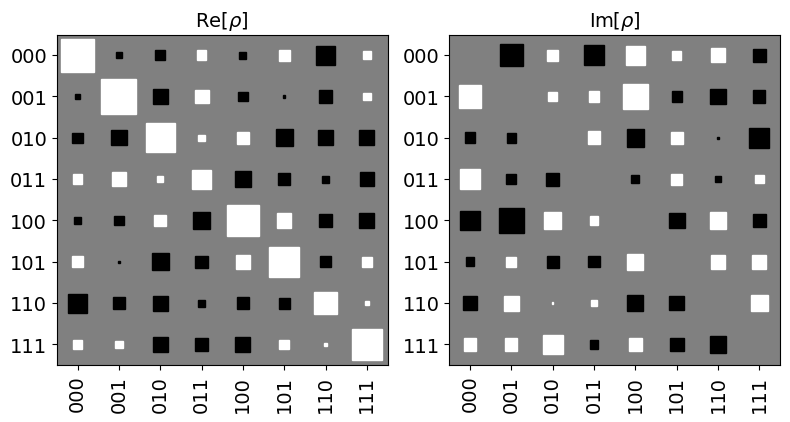

In [8]:
from mipt import *
qc = random_mipt_1d(6, 12, 0.0)
qc.save_density_matrix(qubits=[0,1,2], label='final_state')
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc).result()
sub_m = result.data(0)['final_state']
sub_m.draw("hinton")

Text(0, 0.5, 't_max GNME certification')

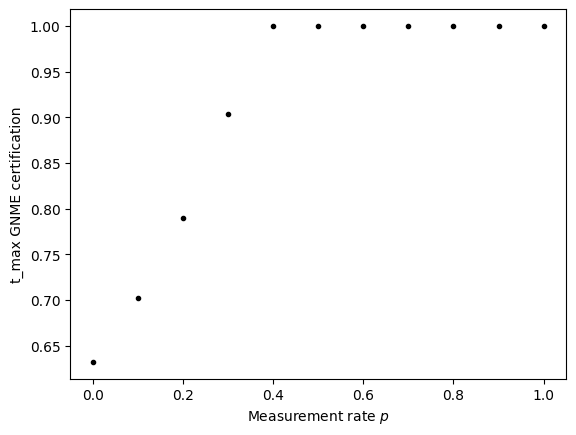

In [3]:
import cvxpy as cp
import numpy as np
from decoded_ring_inflation import ghz_state, decoded_ring_inflation_tmax, white_noise_mixture
import matplotlib.pyplot as plt

psi6 = ghz_state(6)

results = []
ps = np.linspace(0.0, 1.0, 11)

for p in ps:
    print(f"Simulating p = {p}...")
    psi = white_noise_mixture(psi6, p)

    result = decoded_ring_inflation_tmax(
        psi,
        solver=cp.SCS,      # matches the solver reported for inflation in the paper
        verbose=False,
    )
    results.append(result)

plt.scatter(ps, [result.t_max for result in results], c="black", marker=".")
plt.xlabel("Measurement rate $p$")
plt.ylabel("t_max GNME certification")



# print("status:", result.status)
# print("decoded-state t_max:", result.t_max)
# print("decoded-state white-noise boundary:", result.white_noise_at_boundary)
# print("certifies original six-qubit state:", result.certifies_gnme)

In [ ]:
import cvxpy as cp
import numpy as np
from decoded_ring_inflation import ghz_state, decoded_ring_inflation_tmax, white_noise_mixture
import matplotlib.pyplot as plt
from mipt import *

results = []
result_stds = []
ps = np.linspace(0.0, 1.0, 11)

n = 6
depth = 2*n
res = 3

for p in ps:
    
    print(f"Simulating p = {p}...")
    this_result = []
    for _ in range(res):

        backend = AerSimulator(device='CPU')
        qc = random_mipt_1d(n, depth, p, closed=True)
        qc.save_statevector(label='final_state')
        transpiled_qc = transpile(qc, backend)
        result = backend.run(transpiled_qc).result()
        psi = result.data(0)['final_state']

        result = decoded_ring_inflation_tmax(
            psi,
            solver=cp.SCS,      # matches the solver reported for inflation in the paper
            verbose=False,
        )
        this_result.append(result)
    results.append(np.mean([r.t_max for r in this_result]))
    result_stds.append(np.std([r.t_max for r in this_result])/np.sqrt(res))

# plt.scatter(ps, [result.t_max for result in results], c="black", marker=".")
plt.errorbar(ps, results, yerr=result_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
plt.xlabel("Measurement rate $p$")
plt.ylabel("t_max GNME certification")



# print("status:", result.status)
# print("decoded-state t_max:", result.t_max)
# print("decoded-state white-noise boundary:", result.white_noise_at_boundary)
# print("certifies original six-qubit state:", result.certifies_gnme)

Simulating p = 0.0...


/home/communistcanada/mipt/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #16 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


Simulating p = 0.0...


/home/communistcanada/mipt/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #16 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


Simulating p = 0.0...


...

/home/communistcanada/mipt/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #16 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


Simulating p = 0.2...


/home/communistcanada/mipt/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #16 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


Simulating p = 0.2...


/home/communistcanada/mipt/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:173: UserWarning: Constraint #16 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn(f"Constraint #{i} contains too many subexpressions. "


[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ] [0.999999594864968, 1.0000003495918999, 0.9999999605451958, 1.0000030979048586, 0.999999986965643, 0.9999977691886042, 0.9999998543423397, 1.0000017284504303, 1.00000000143531, 1.0000001534859964, 1.0000000014353088]


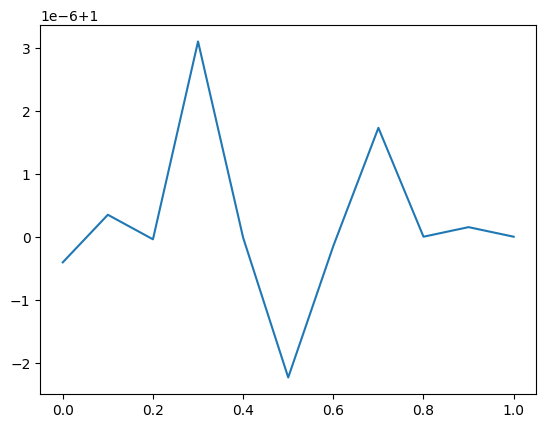

In [4]:
print(ps, [result.t_max for result in results])
plt.plot(ps, [result.t_max for result in results])